In [1]:
import os
import json
import csv
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem

# 加载前期工具函数（Day4/5/6）
scripts = r"C:\Users\pc\Desktop\2026DiffMS\scripts"
exec(open(os.path.join(scripts, "04_graph_utils.py"), encoding="utf-8").read());
exec(open(os.path.join(scripts, "05_diffusion.py"), encoding="utf-8").read());
exec(open(os.path.join(scripts, "06_graph_decoder.py"), encoding="utf-8").read());

###############################################
# 一、加载两个预训练模型
###############################################

####
# 1.1 谱编码器（Day9训好的）
# 结构必须和训练时一模一样：1000→512→256→2048
spec_encoder = nn.Sequential(
    nn.Linear(1000, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 2048)
);
checkpoint_path = r"C:\Users\pc\Desktop\2026DiffMS\checkpoints\spec_encoder.pth";
if os.path.exists(checkpoint_path):
    spec_encoder.load_state_dict(torch.load(checkpoint_path, map_location="cpu"));
    print("谱编码器权重已加载");
else:
    print("警告: 未找到谱编码器权重，将从头开始");

####
# 1.2 图解码器（Day8训好的）
# edge_denoiser 已在 06_graph_decoder.py 里定义为全局变量，直接加载即可
decoder_path = r"C:\Users\pc\Desktop\2026DiffMS\checkpoints\edge_denoiser_2000.pth";
if os.path.exists(decoder_path):
    edge_denoiser.load_state_dict(torch.load(decoder_path, map_location="cpu"));
    print("图解码器权重已加载");
else:
    print("警告: 未找到图解码器权重，将从头开始");

print("\n两个模型加载完成，准备端到端微调");

谱编码器权重已加载
图解码器权重已加载

两个模型加载完成，准备端到端微调


In [2]:
# 二、谱图向量化（复用 Day9 的同名函数）
def binned_spectrum(mz_list, inten_list, max_mz=1000, bin_size=1.0):
    n_bins = int(max_mz / bin_size);
    vec = np.zeros(n_bins, dtype=np.float32);
    for mz, inten in zip(mz_list, inten_list):
        if 0 <= mz < max_mz:
            idx = int(mz / bin_size);
            vec[idx] = max(vec[idx], float(inten));
    if vec.max() > 0:
        vec = vec / vec.max();
    return vec;

In [7]:
# 三、加载端到端训练数据（谱 + 分子图配对）
data_dir = r"C:\Users\pc\Desktop\2026DiffMS\data\canopus";
labels_path = os.path.join(data_dir, "labels.tsv");
spec_dir = os.path.join(data_dir, "subformulae", "subformulae_default");

all_data = [];
failed_spec = 0;    # 谱文件缺失
failed_mol = 0;     # 分子解析失败

with open(labels_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f, delimiter="\t");
    for row in reader:
        spec = row["spec"];
        smiles = row["smiles"];
        json_path = os.path.join(spec_dir, spec + ".json");

        # 3.1 读谱文件，向量化
        if not os.path.exists(json_path):
            failed_spec += 1;
            continue;
        with open(json_path, "r") as jf:
            obj = json.load(jf);
        mz = obj["output_tbl"]["mz"];
        inten = obj["output_tbl"]["ms2_inten"];
        spec_vec = binned_spectrum(mz, inten);

        # 3.2 SMILES → 分子图
        mol = Chem.MolFromSmiles(smiles);
        if mol is None:
            failed_mol += 1;
            continue;
        A0, atom_symbols = build_adj(mol);
        fp = get_fingerprint(mol);
        atom_types = get_atom_one_hot(atom_symbols);
        A0_labels = np.argmax(A0, axis=-1);

        # 3.3 存成一个字典
        all_data.append({
            'spec_vec': spec_vec,       # 谱向量（喂给spec_encoder）
            'A0': A0,                   # 邻接矩阵
            'A0_labels': A0_labels,     # 键类型标签
            'atom_types': atom_types,   # 原子 one-hot
            'fp': fp,                   # 真实指纹（评估用）
            'smiles': smiles,
        });

        if len(all_data) >= 500:  # 先取500条做小规模实验
            break;

print(f"加载完成: {len(all_data)} 条样本");
print(f"谱文件缺失: {failed_spec}, 分子解析失败: {failed_mol}");
print(f"第1条 spec_vec 形状: {all_data[0]['spec_vec'].shape}");
print(f"第1条 A0 形状: {all_data[0]['A0'].shape}");

加载完成: 500 条样本
谱文件缺失: 0, 分子解析失败: 0
第1条 spec_vec 形状: (1000,)
第1条 A0 形状: (53, 53, 5)


In [5]:
# 四、端到端微调训练
# 4.1 设置优化器、损失函数、噪声调度
optimizer = torch.optim.Adam(
    list(spec_encoder.parameters()) + list(edge_denoiser.parameters()),
    lr=1e-4
);
loss_fn = nn.CrossEntropyLoss();      # 和Day8一样，预测键类型
alpha_bars = get_noise_schedule(500);  # 和Day5一样

####
# 4.2 训练循环
num_epochs = 30;   #跑的总次数
loss_history = [];

print("\n开始端到端训练");
for epoch in range(num_epochs):
    total_loss = 0.0;
    for data in all_data:   #遍历每个样本
        #谱向量 → spec_encoder → 条件向量
        spec_tensor = torch.tensor(data['spec_vec'], dtype=torch.float32);
        condition = spec_encoder(spec_tensor);   # (2048,) 连续值

        #随机选时间步 + 加噪（和Day8完全一样）
        t = sample_timesteps(1, 500)[0];
        At = q_sample(data['A0'].copy(), t, alpha_bars);

        #提取边特征：把条件向量拼进去
        #build_init_feature 用numpy，so先转np
        condition_np = condition.detach().numpy();
        features = build_init_feature(data['atom_types'], At, condition_np);

        #取上三角所有边的真实标签
        n = data['A0'].shape[0];
        i_idx, j_idx = np.triu_indices(n, k=1);
        targets = data['A0_labels'][i_idx, j_idx];

        #模型预测+算loss
        logits = edge_denoiser(torch.tensor(features));
        loss = loss_fn(logits, torch.tensor(targets, dtype=torch.long));

        #反向传播 + 参数更新
        optimizer.zero_grad();
        loss.backward();
        optimizer.step();
        total_loss += loss.item();

    avg_loss = total_loss / len(all_data);
    loss_history.append(avg_loss);
    print(f"Epoch {epoch+1:2d}/{num_epochs}, loss = {avg_loss:.4f}");

print("\n30轮试跑完成");


开始端到端训练
Epoch  1/30, loss = 0.3963
Epoch  2/30, loss = 0.3934
Epoch  3/30, loss = 0.3915
Epoch  4/30, loss = 0.3905
Epoch  5/30, loss = 0.3904
Epoch  6/30, loss = 0.3894
Epoch  7/30, loss = 0.3885
Epoch  8/30, loss = 0.3870
Epoch  9/30, loss = 0.3870
Epoch 10/30, loss = 0.3872
Epoch 11/30, loss = 0.3867
Epoch 12/30, loss = 0.3853
Epoch 13/30, loss = 0.3867
Epoch 14/30, loss = 0.3871
Epoch 15/30, loss = 0.3870
Epoch 16/30, loss = 0.3864
Epoch 17/30, loss = 0.3859
Epoch 18/30, loss = 0.3860
Epoch 19/30, loss = 0.3856
Epoch 20/30, loss = 0.3854
Epoch 21/30, loss = 0.3858
Epoch 22/30, loss = 0.3850
Epoch 23/30, loss = 0.3846
Epoch 24/30, loss = 0.3845
Epoch 25/30, loss = 0.3846
Epoch 26/30, loss = 0.3830
Epoch 27/30, loss = 0.3832
Epoch 28/30, loss = 0.3826
Epoch 29/30, loss = 0.3823
Epoch 30/30, loss = 0.3818

30轮试跑完成


In [6]:
# 五、端到端采样：谱 → 编码器 → 解码器 → 分子图
def sample_molecule(spec_vec, atom_types, atom_symbols_list, num_steps=500):
    n = atom_types.shape[0];

    # ① 谱向量 → spec_encoder → 条件向量
    spec_tensor = torch.tensor(spec_vec, dtype=torch.float32);
    with torch.no_grad():
        condition = spec_encoder(spec_tensor).numpy();

    # ② 从纯随机噪声开始
    At = np.zeros((n, n, 5), dtype=np.float32);
    np.fill_diagonal(At[:, :, 0], 1);  # 对角线无键

    # ③ 逐步去噪：t 从499到0
    for t in range(num_steps - 1, -1, -1):
        features = build_init_feature(atom_types, At, condition);
        with torch.no_grad():
            logits = edge_denoiser(torch.tensor(features));
            preds = torch.argmax(logits, dim=1).numpy();

        # 填回 At
        i_idx, j_idx = np.triu_indices(n, k=1);
        At_new = np.zeros_like(At);
        np.fill_diagonal(At_new[:, :, 0], 1);
        for k in range(len(i_idx)):
            At_new[i_idx[k], j_idx[k], preds[k]] = 1;
            At_new[j_idx[k], i_idx[k], preds[k]] = 1;
        At = At_new;

    # ④ 检查合法性
    mol = adj_to_mol(atom_symbols_list, At);
    return mol;

####
# 5.1 对前50个样本采样，统计validity
num_samples = 50;
valid_count = 0;
for i in range(num_samples):
    data = all_data[i];
    # 从atom_types还原原子符号列表
    atom_symbols_list = [];
    for ai in range(data['atom_types'].shape[0]):
        found = False;
        for sym, idx in atom_maps.items():
            if data['atom_types'][ai, idx] == 1.0:
                atom_symbols_list.append(sym);
                found = True;
                break;
        if not found:
            atom_symbols_list.append('C');  # 兜底

    mol = sample_molecule(data['spec_vec'], data['atom_types'], atom_symbols_list);
    if mol is not None:
        valid_count += 1;

validity = valid_count / num_samples;
print(f"端到端 Validity: {validity:.2%} ({valid_count}/{num_samples})");

端到端 Validity: 100.00% (50/50)


In [8]:
###############################################
# 六、Tanimoto 相似度评估
###############################################

from rdkit import DataStructs;

num_eval = 50;
tanimoto_list = [];
valid_for_tan = 0;

for i in range(num_eval):
    data = all_data[i];

    # 还原原子符号列表
    atom_symbols_list = [];
    for ai in range(data['atom_types'].shape[0]):
        found = False;
        for sym, idx in atom_maps.items():
            if data['atom_types'][ai, idx] == 1.0:
                atom_symbols_list.append(sym);
                found = True;
                break;
        if not found:
            atom_symbols_list.append('C');

    # 采样生成分子
    mol = sample_molecule(data['spec_vec'], data['atom_types'], atom_symbols_list);
    if mol is not None:
        valid_for_tan += 1;

        # 生成分子的指纹
        gen_fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048);
        # 真实分子的指纹（从data里直接取，不用重新算）
        ref_fp_bits = "".join([str(int(b)) for b in data['fp']]);
        ref_fp = DataStructs.CreateFromBitString(ref_fp_bits);

        tan = DataStructs.TanimotoSimilarity(gen_fp, ref_fp);
        tanimoto_list.append(tan);

avg_tan = np.mean(tanimoto_list) if tanimoto_list else 0.0;
print(f"端到端平均 Tanimoto 相似度: {avg_tan:.4f} (有效分子: {valid_for_tan}/{num_eval})");

端到端平均 Tanimoto 相似度: 0.0015 (有效分子: 50/50)


Loss曲线已保存到 images/DAY10/loss_curve.png
端到端模型权重已保存

Day10 端到端微调完成


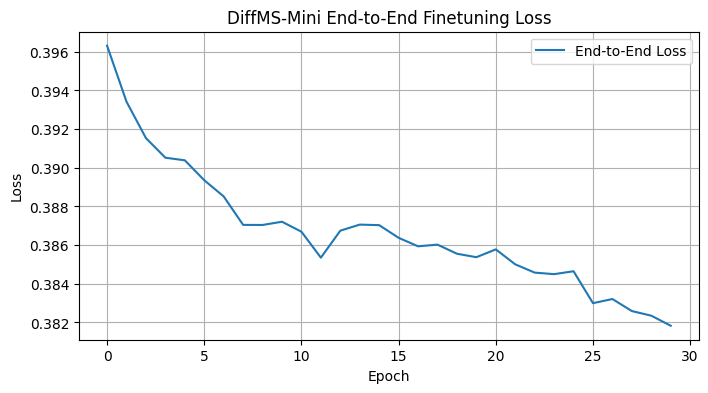

In [11]:
# 七、保存结果
os.makedirs("../images/DAY10", exist_ok=True);

plt.figure(figsize=(8, 4));
plt.plot(loss_history, label="End-to-End Loss");
plt.xlabel("Epoch");
plt.ylabel("Loss");
plt.title("DiffMS-Mini End-to-End Finetuning Loss");
plt.legend();
plt.grid(True);
plt.savefig("../images/DAY10/loss_curve.png", dpi=150, bbox_inches="tight");
print("Loss曲线已保存到 images/DAY10/loss_curve.png");

os.makedirs("../logs", exist_ok=True);
with open("../logs/day10_end2end_log.txt", "w") as f:
    f.write(f"Validity: {validity:.4f}\n");
    f.write(f"Tanimoto: {avg_tan:.4f}\n");
    for i, loss in enumerate(loss_history):
        f.write(f"Epoch {i+1}: loss={loss:.4f}\n");

torch.save(spec_encoder.state_dict(), "../checkpoints/spec_encoder_e2e.pth");
torch.save(edge_denoiser.state_dict(), "../checkpoints/edge_denoiser_e2e.pth");
print("端到端模型权重已保存");
print("\nDay10 端到端微调完成");